In [13]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [14]:
from pydantic import BaseModel, Field

class EmotionBotState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 메시지")
    emotion: str = Field(default="", description="분석된 감정")
    response: str = Field(default="", description="최종 응답 메시지")

In [15]:
from langchain_core.messages import SystemMessage, HumanMessage

def analyze_emotion(state: EmotionBotState) -> EmotionBotState:
    message = state.user_message

    messages = [
        SystemMessage(content="""당신은 감정 분석 전문가입니다.
사용자의 메시지를 분석하여 'positive', 'negative', 'neutral' 중 하나로 감정을 분류해 주세요.
답변은 반드시 하나의 단어만 출력하세요."""),
        HumanMessage(content=f"다음 메시지의 감정을 분석해주세요: {message}")
    ]

    response = model.invoke(messages)
    emotion = response.content.strip().lower()

    if emotion not in ['positive', 'negative', 'neutral']:
        emotion = 'neutral'
    
    return {"emotion": emotion}

In [16]:
def generate_positive_response(state: EmotionBotState) -> EmotionBotState:
    return {"response": "😊"}

def generate_negative_response(state: EmotionBotState) -> EmotionBotState:
    return {"response": "😟"}

def generate_neutral_response(state: EmotionBotState) -> EmotionBotState:
    return {"response": "😑"}

In [17]:
def route_by_emotion(state: EmotionBotState):
    emotion = state.emotion

    if emotion == "positive":
        return "positive_response"
    elif emotion == "negative":
        return "negative_response"
    else:
        return "neutral_response"

In [18]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(EmotionBotState)

graph_builder.add_node("analyze", analyze_emotion)
graph_builder.add_node("positive_response", generate_positive_response)
graph_builder.add_node("negative_response", generate_negative_response)
graph_builder.add_node("neutral_response", generate_neutral_response)

graph_builder.add_edge(START, "analyze")
graph_builder.add_conditional_edges(
    "analyze", 
    route_by_emotion, 
    {
        "positive_response": "positive_response",
        "negative_response": "negative_response",
        "neutral_response": "neutral_response",
    }
)

graph_builder.add_edge("positive_response", END)
graph_builder.add_edge("negative_response", END)
graph_builder.add_edge("neutral_response", END)

graph = graph_builder.compile()

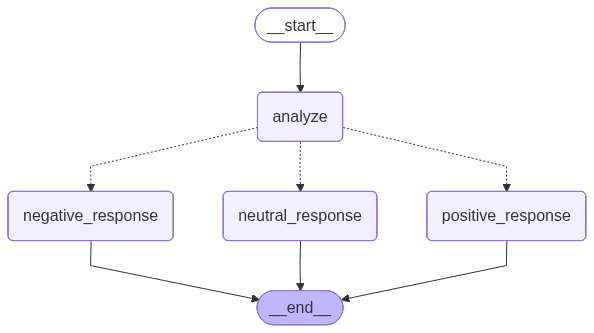

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response = graph.invoke({"user_message": "기분이 좋습니다."})

In [23]:
response["response"]

'😊'

In [24]:
response = graph.invoke({"user_message": "배가 많이 고픕니다."})

In [25]:
response["response"]

'😟'

In [26]:
response = graph.invoke({"user_message": "랭체인 공부하고 있습니다."})

In [28]:
response["response"]

'😑'